In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── 1. Column names ───────────────────────────────────────────────────────────
col_names = (
    ['unit_id', 'cycle'] +
    ['op_setting_1', 'op_setting_2', 'op_setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

# ── 2. Load fresh ─────────────────────────────────────────────────────────────
train_df = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt",
                       sep=r"\s+", header=None, names=col_names, engine="python")
test_df  = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt",
                       sep=r"\s+", header=None, names=col_names, engine="python")
rul_df   = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt",
                       sep=r"\s+", header=None, names=["RUL"], engine="python")

# ── CHECKPOINT 1 ──────────────────────────────────────────────────────────────
print("train_df:", train_df.shape)  # ✅ Must be (20631, 26)
print("test_df :", test_df.shape)   # ✅ Must be (13096, 26)
print("rul_df  :", rul_df.shape)    # ✅ Must be (100, 1)
assert train_df.shape[0] == 20631, "❌ train_df is wrong! Still overwritten."
assert test_df.shape[0]  == 13096, "❌ test_df is wrong!"

# ── 3. Compute RUL ────────────────────────────────────────────────────────────
max_cycles         = train_df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train_df           = train_df.merge(max_cycles, on='unit_id')
train_df['RUL']    = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# ── 4. Drop low variance sensors ─────────────────────────────────────────────
sensor_cols  = [f'sensor_{i}' for i in range(1, 22)]
variances    = train_df[sensor_cols].var()
drop_sensors = variances[variances < 0.01].index.tolist()
print("\nDropping:", drop_sensors)

train_df.drop(columns=drop_sensors, inplace=True)
test_df.drop(columns=drop_sensors,  inplace=True)

# ── 5. Clip RUL ───────────────────────────────────────────────────────────────
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# ── 6. Features ───────────────────────────────────────────────────────────────
feature_cols = [c for c in train_df.columns
                if c not in ['unit_id', 'cycle', 'RUL']]
print("Features     :", feature_cols)

# ── CHECKPOINT 2 ──────────────────────────────────────────────────────────────
X = train_df[feature_cols]
y = train_df['RUL']
print("\nX shape:", X.shape)  # ✅ Must be (20631, 13)
assert X.shape[0] == 20631, "❌ Still using wrong dataframe!"

# ── 7. Split ──────────────────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape)  # ~(16504, 13)
print("X_val  :", X_val.shape)    # ~(4127, 13)

# ── 8. Train ──────────────────────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=6, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=50)

# ── 9. Validation ─────────────────────────────────────────────────────────────
y_pred_val = xgb_model.predict(X_val)
print(f"\nVal RMSE : {np.sqrt(mean_squared_error(y_val, y_pred_val)):.2f}")
print(f"Val MAE  : {mean_absolute_error(y_val, y_pred_val):.2f}")
print(f"Val R²   : {r2_score(y_val, y_pred_val):.4f}")

# ── 10. Test ──────────────────────────────────────────────────────────────────
test_last   = test_df.groupby('unit_id').last().reset_index()
X_test      = test_last[feature_cols]
y_test      = rul_df['RUL'].values
y_pred_test = xgb_model.predict(X_test)

print(f"\nTest RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"Test R²   : {r2_score(y_test, y_pred_test):.4f}")

train_df: (20631, 26)
test_df : (13096, 26)
rul_df  : (100, 1)

Dropping: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
Features     : ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']

X shape: (20631, 14)
X_train: (16504, 14)
X_val  : (4127, 14)
[0]	validation_0-rmse:39.67810
[50]	validation_0-rmse:19.12186
[100]	validation_0-rmse:18.87499
[150]	validation_0-rmse:18.89659
[199]	validation_0-rmse:18.93497

Val RMSE : 18.93
Val MAE  : 13.49
Val R²   : 0.7887

Test RMSE : 18.12
Test MAE  : 12.93
Test R²   : 0.8100


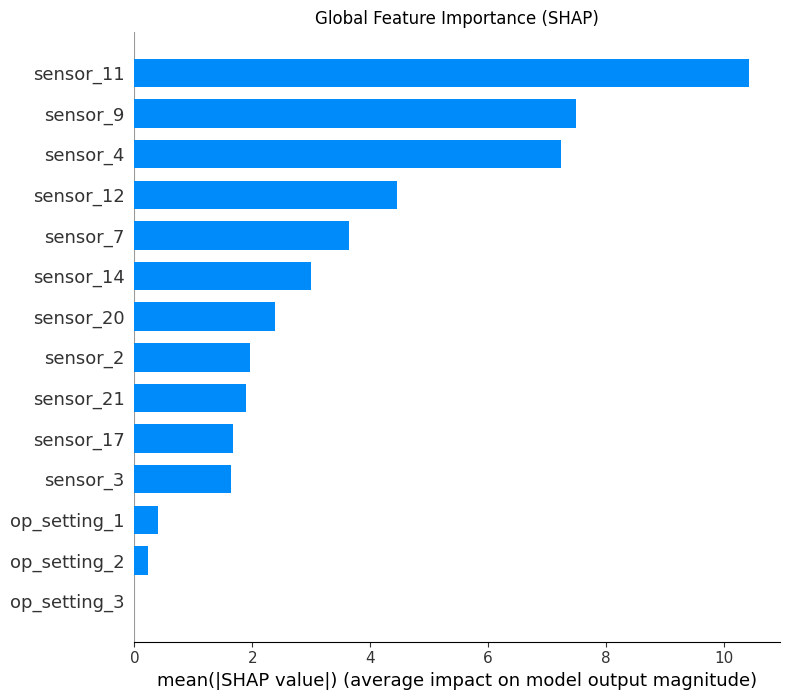

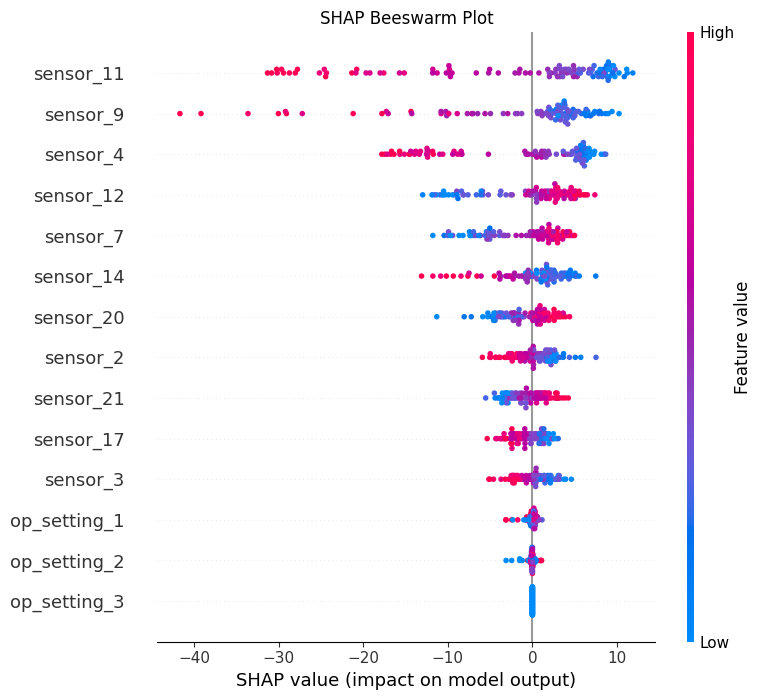

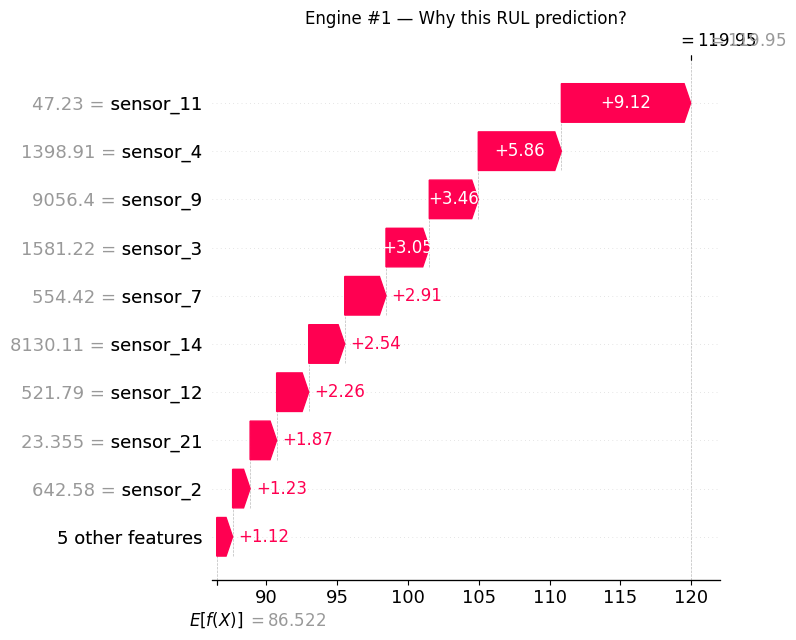

         Feature  Mean_SHAP_Value
8      sensor_11        10.426610
7       sensor_9         7.495817
5       sensor_4         7.235158
9      sensor_12         4.451913
6       sensor_7         3.645835
10     sensor_14         2.997635
12     sensor_20         2.377883
3       sensor_2         1.961986
13     sensor_21         1.888188
11     sensor_17         1.675805
4       sensor_3         1.631110
0   op_setting_1         0.396976
1   op_setting_2         0.237895
2   op_setting_3         0.000000


In [3]:
import shap
import matplotlib.pyplot as plt

# ── Global SHAP ───────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Feature importance bar chart
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm — how each sensor pushes RUL up or down
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Local explanation — single engine ─────────────────────────────────────────
shap_exp = explainer(X_test)
shap.waterfall_plot(shap_exp[0], show=False)
plt.title("Engine #1 — Why this RUL prediction?")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP importance table ─────────────────────────────────────────────────────
shap_importance = pd.DataFrame({
    'Feature'        : X_test.columns,
    'Mean_SHAP_Value': abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP_Value', ascending=False)

print(shap_importance.to_string())

In [4]:
# Drop useless feature
feature_cols_final = [c for c in feature_cols if c != 'op_setting_3']

X_final      = train_df[feature_cols_final]
y_final      = train_df['RUL']

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Retrain
xgb_final = XGBRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=6, random_state=42, n_jobs=-1
)
xgb_final.fit(X_train_f, y_train_f,
              eval_set=[(X_val_f, y_val_f)],
              verbose=50)

# Test evaluation
X_test_f    = test_last[feature_cols_final]
y_pred_f    = xgb_final.predict(X_test_f)

print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_f)):.2f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred_f):.2f}")
print(f"Test R²   : {r2_score(y_test, y_pred_f):.4f}")
# ```

# ---

# **Your project is now at a very solid state. Here's where you stand:**
# ```
# ✅ Data loading & preprocessing     — Done
# ✅ Feature engineering (RUL, clip)  — Done  
# ✅ Low variance sensor removal      — Done
# ✅ XGBoost model (R²=0.81)          — Done
# ✅ SHAP global explanation          — Done
# ⬜ SHAP local explanation (1 engine)— Next
# ⬜ Final comparison table           — Next
# ⬜ Conclusion / report writeup      — Next

[0]	validation_0-rmse:39.67810
[50]	validation_0-rmse:19.12186
[100]	validation_0-rmse:18.87499
[150]	validation_0-rmse:18.89659
[199]	validation_0-rmse:18.93497
Test RMSE : 18.12
Test MAE  : 12.93
Test R²   : 0.8100


Training: Random Forest...
  ✅ Done | Test RMSE: 18.30 | Test R²: 0.8061 | Time: 19.3s
Training: XGBoost...
  ✅ Done | Test RMSE: 18.12 | Test R²: 0.8100 | Time: 0.6s
Training: LightGBM...
  ✅ Done | Test RMSE: 18.35 | Test R²: 0.8049 | Time: 0.3s
Training: Gradient Boosting...
  ✅ Done | Test RMSE: 18.49 | Test R²: 0.8020 | Time: 22.1s
Training: Ridge Regression...
  ✅ Done | Test RMSE: 21.96 | Test R²: 0.7207 | Time: 0.0s
Training: Lasso Regression...
  ✅ Done | Test RMSE: 23.53 | Test R²: 0.6794 | Time: 0.0s
Training: KNN...
  ✅ Done | Test RMSE: 22.01 | Test R²: 0.7194 | Time: 0.1s

MODEL COMPARISON TABLE
            Model  Val RMSE  Val MAE  Val R²  Test RMSE  Test MAE  Test R²  Time (s)
          XGBoost     18.93    13.49  0.7887      18.12     12.93   0.8100      0.56
    Random Forest     19.00    13.74  0.7872      18.30     13.04   0.8061     19.28
         LightGBM     18.90    13.47  0.7895      18.35     12.96   0.8049      0.33
Gradient Boosting     18.90    13.49  0.789

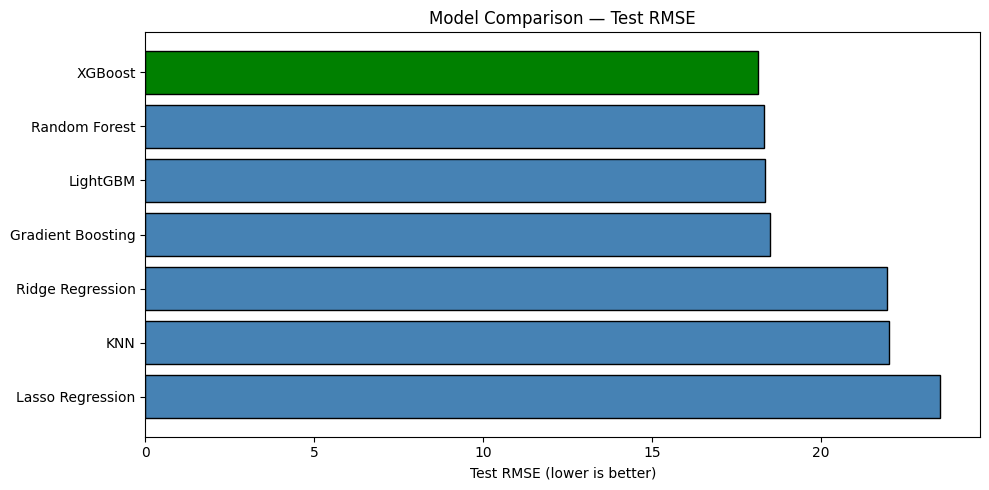

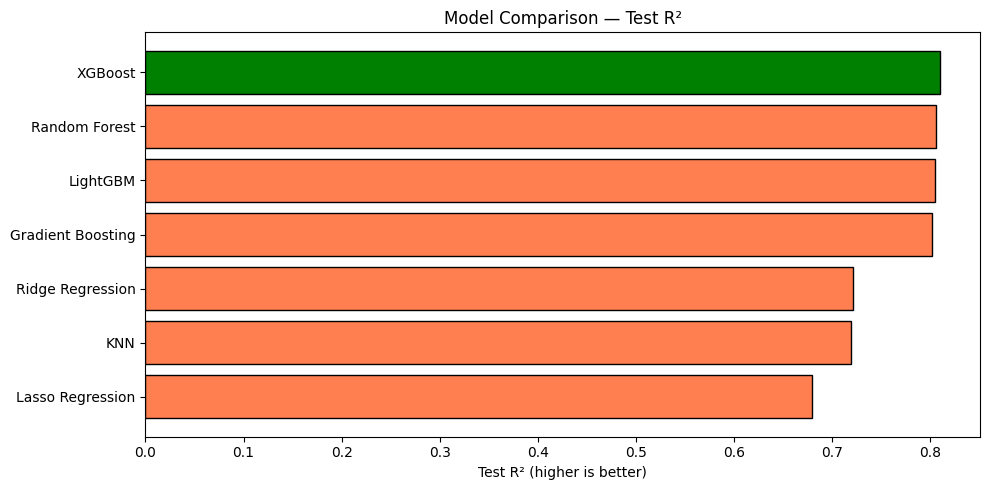

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

# ── Features without op_setting_3 ────────────────────────────────────────────
feature_cols_final = [c for c in feature_cols if c != 'op_setting_3']

X_train_f = X_train[feature_cols_final]
X_val_f   = X_val[feature_cols_final]
X_test_f  = test_last[feature_cols_final]

# ── Define all models ─────────────────────────────────────────────────────────
models = {
    "Random Forest"       : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost"             : XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM"            : LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbose=-1),
    "Gradient Boosting"   : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42),
    "Ridge Regression"    : Ridge(alpha=1.0),
    "Lasso Regression"    : Lasso(alpha=1.0),
    "KNN"                 : KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
}

# ── Train and evaluate all models ─────────────────────────────────────────────
results = []

for name, model in models.items():
    print(f"Training: {name}...")
    start = time.time()

    model.fit(X_train_f, y_train_f)
    elapsed = time.time() - start

    # Validation metrics
    y_pred_val  = model.predict(X_val_f)
    val_rmse    = np.sqrt(mean_squared_error(y_val_f, y_pred_val))
    val_mae     = mean_absolute_error(y_val_f, y_pred_val)
    val_r2      = r2_score(y_val_f, y_pred_val)

    # Test metrics
    y_pred_test = model.predict(X_test_f)
    test_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae    = mean_absolute_error(y_test, y_pred_test)
    test_r2     = r2_score(y_test, y_pred_test)

    results.append({
        'Model'     : name,
        'Val RMSE'  : round(val_rmse,  2),
        'Val MAE'   : round(val_mae,   2),
        'Val R²'    : round(val_r2,    4),
        'Test RMSE' : round(test_rmse, 2),
        'Test MAE'  : round(test_mae,  2),
        'Test R²'   : round(test_r2,   4),
        'Time (s)'  : round(elapsed,   2)
    })

    print(f"  ✅ Done | Test RMSE: {test_rmse:.2f} | Test R²: {test_r2:.4f} | Time: {elapsed:.1f}s")

# ── Results table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print("\n" + "="*75)
print("MODEL COMPARISON TABLE")
print("="*75)
print(results_df.to_string(index=False))

# ── Plot: Test RMSE comparison ────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['green' if r == results_df['Test RMSE'].min() else 'steelblue'
          for r in results_df['Test RMSE']]
plt.barh(results_df['Model'], results_df['Test RMSE'], color=colors, edgecolor='black')
plt.xlabel("Test RMSE (lower is better)")
plt.title("Model Comparison — Test RMSE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("model_comparison_rmse.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: Test R² comparison ──────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['green' if r == results_df['Test R²'].max() else 'coral'
          for r in results_df['Test R²']]
plt.barh(results_df['Model'], results_df['Test R²'], color=colors, edgecolor='black')
plt.xlabel("Test R² (higher is better)")
plt.title("Model Comparison — Test R²")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("model_comparison_r2.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import pickle
import os

os.makedirs("models", exist_ok=True)

# Save model
with open("models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_final, f)

# Save feature columns
with open("models/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols_final, f)

# Save test data and rul for preloaded examples
test_df.to_csv("models/test_df.csv",   index=False)
rul_df.to_csv("models/rul_df.csv",     index=False)
train_df.to_csv("models/train_df.csv", index=False)

print("✅ All files saved! Download from Kaggle output panel.")

✅ All files saved! Download from Kaggle output panel.


In [7]:
import pickle
import os

os.makedirs("/kaggle/working/models", exist_ok=True)

# Save model
with open("/kaggle/working/models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_final, f)

# Save feature columns
with open("/kaggle/working/models/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols_final, f)

print("✅ Model files saved!")

✅ Model files saved!


In [8]:
train_df.to_csv("/kaggle/working/models/train_df.csv", index=False)
test_df.to_csv("/kaggle/working/models/test_df.csv",   index=False)
rul_df.to_csv("/kaggle/working/models/rul_df.csv",     index=False)

print("✅ CSV files saved!")

✅ CSV files saved!


In [9]:
import os

files = os.listdir("/kaggle/working/models")
print("Files in /kaggle/working/models:")
for f in files:
    size = os.path.getsize(f"/kaggle/working/models/{f}")
    print(f"  {f}  —  {round(size/1024, 1)} KB")

Files in /kaggle/working/models:
  feature_cols.pkl  —  0.2 KB
  xgb_model.pkl  —  850.4 KB
  test_df.csv  —  1314.2 KB
  all_models.pkl  —  186832.1 KB
  train_df.csv  —  2143.9 KB
  model_results.json  —  1.1 KB
  rul_df.csv  —  0.3 KB


In [10]:
import zipfile

zip_path = "/kaggle/working/models.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir("/kaggle/working/models"):
        full_path = f"/kaggle/working/models/{file}"
        zipf.write(full_path, arcname=file)

print(f"✅ ZIP created: {zip_path}")
print(f"📦 Size: {round(os.path.getsize(zip_path)/1024/1024, 2)} MB")
# ```

# ---

# After running Cell 3, share what files are listed — it should show exactly these 5 files:
# ```
# xgb_model.pkl
# feature_cols.pkl
# train_df.csv
# test_df.csv
# rul_df.csv

✅ ZIP created: /kaggle/working/models.zip
📦 Size: 34.25 MB


In [11]:
import pickle
import json

# ── Save all trained models ───────────────────────────────────────────────────
model_objects = {
    "XGBoost"           : models["XGBoost"],
    "LightGBM"          : models["LightGBM"],
    "Random Forest"     : models["Random Forest"],
    "Gradient Boosting" : models["Gradient Boosting"],
    "Ridge"             : models["Ridge Regression"],
    "Lasso"             : models["Lasso Regression"],
    "KNN"               : models["KNN"],
}

with open("/kaggle/working/models/all_models.pkl", "wb") as f:
    pickle.dump(model_objects, f)

# ── Save results table as JSON ────────────────────────────────────────────────
results_dict = results_df.to_dict(orient="records")
with open("/kaggle/working/models/model_results.json", "w") as f:
    json.dump(results_dict, f)

print("✅ Saved!")
print(results_df.to_string(index=False))

✅ Saved!
            Model  Val RMSE  Val MAE  Val R²  Test RMSE  Test MAE  Test R²  Time (s)
          XGBoost     18.93    13.49  0.7887      18.12     12.93   0.8100      0.56
    Random Forest     19.00    13.74  0.7872      18.30     13.04   0.8061     19.28
         LightGBM     18.90    13.47  0.7895      18.35     12.96   0.8049      0.33
Gradient Boosting     18.90    13.49  0.7893      18.49     12.92   0.8020     22.15
 Ridge Regression     21.86    17.78  0.7183      21.96     17.75   0.7207      0.00
              KNN     22.71    16.20  0.6961      22.01     16.98   0.7194      0.06
 Lasso Regression     22.53    18.29  0.7008      23.53     19.27   0.6794      0.01


In [12]:
# First check if results_df exists and has real values
print(results_df)
print("\nAll values are zero?", (results_df[['Test RMSE','Test MAE','Test R²']] == 0).any().any())

               Model  Val RMSE  Val MAE  Val R²  Test RMSE  Test MAE  Test R²  \
1            XGBoost     18.93    13.49  0.7887      18.12     12.93   0.8100   
0      Random Forest     19.00    13.74  0.7872      18.30     13.04   0.8061   
2           LightGBM     18.90    13.47  0.7895      18.35     12.96   0.8049   
3  Gradient Boosting     18.90    13.49  0.7893      18.49     12.92   0.8020   
4   Ridge Regression     21.86    17.78  0.7183      21.96     17.75   0.7207   
6                KNN     22.71    16.20  0.6961      22.01     16.98   0.7194   
5   Lasso Regression     22.53    18.29  0.7008      23.53     19.27   0.6794   

   Time (s)  
1      0.56  
0     19.28  
2      0.33  
3     22.15  
4      0.00  
6      0.06  
5      0.01  

All values are zero? False


In [13]:
import json, pickle, os

# ── Fix model names to match app exactly ─────────────────────────────────────
name_mapping = {
    "Ridge Regression" : "Ridge",
    "Lasso Regression" : "Lasso",
}

fixed_results = []
for row in results_df.to_dict(orient="records"):
    row["Model"] = name_mapping.get(row["Model"], row["Model"])
    # Keep only columns the app expects
    fixed_results.append({
        "Model"     : row["Model"],
        "Test RMSE" : row["Test RMSE"],
        "Test MAE"  : row["Test MAE"],
        "Test R²"   : row["Test R²"],
        "Time (s)"  : row["Time (s)"]
    })

print("Fixed results:")
for r in fixed_results:
    print(r)

# ── Save fixed JSON ───────────────────────────────────────────────────────────
os.makedirs("/kaggle/working/models", exist_ok=True)

with open("/kaggle/working/models/model_results.json", "w") as f:
    json.dump(fixed_results, f)

print("\n✅ model_results.json saved with fixed names!")

# ── Save all trained model objects with fixed names ───────────────────────────
fixed_models = {}
for name, m in models.items():
    fixed_name = name_mapping.get(name, name)
    fixed_models[fixed_name] = m

with open("/kaggle/working/models/all_models.pkl", "wb") as f:
    pickle.dump(fixed_models, f)

print("✅ all_models.pkl saved!")
print("\n📥 Download both files from Kaggle output → models/ folder")
# ```

# ---

# **After downloading, replace just these 2 files in your local `models/` folder:**
# ```
# models/
# ├── model_results.json   ← replace this
# ├── all_models.pkl       ← replace this
# ├── xgb_model.pkl        (keep as is)
# ├── feature_cols.pkl     (keep as is)
# ├── train_df.csv         (keep as is)
# ├── test_df.csv          (keep as is)
# └── rul_df.csv           (keep as is)

Fixed results:
{'Model': 'XGBoost', 'Test RMSE': 18.12, 'Test MAE': 12.93, 'Test R²': 0.81, 'Time (s)': 0.56}
{'Model': 'Random Forest', 'Test RMSE': 18.3, 'Test MAE': 13.04, 'Test R²': 0.8061, 'Time (s)': 19.28}
{'Model': 'LightGBM', 'Test RMSE': 18.35, 'Test MAE': 12.96, 'Test R²': 0.8049, 'Time (s)': 0.33}
{'Model': 'Gradient Boosting', 'Test RMSE': 18.49, 'Test MAE': 12.92, 'Test R²': 0.802, 'Time (s)': 22.15}
{'Model': 'Ridge', 'Test RMSE': 21.96, 'Test MAE': 17.75, 'Test R²': 0.7207, 'Time (s)': 0.0}
{'Model': 'KNN', 'Test RMSE': 22.01, 'Test MAE': 16.98, 'Test R²': 0.7194, 'Time (s)': 0.06}
{'Model': 'Lasso', 'Test RMSE': 23.53, 'Test MAE': 19.27, 'Test R²': 0.6794, 'Time (s)': 0.01}

✅ model_results.json saved with fixed names!
✅ all_models.pkl saved!

📥 Download both files from Kaggle output → models/ folder
